# Análisis de ventas y comportamiento comercial de un eCommerce

## Objetivo del proyecto

Analizar las transacciones de un eCommerce para identificar los productos, mercados y periodos que generan mayores ingresos, así como detectar patrones de compra, cancelaciones y oportunidades de mejora comercial.

## Pregunta de negocio

**¿Qué productos, mercados y periodos impulsan los ingresos del eCommerce y qué oportunidades existen para mejorar su desempeño comercial?**

### Herramientas

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook / Google Colab


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Exploración inicial de los datos

Antes de realizar el análisis, se revisará la estructura y calidad del dataset
para identificar tipos de datos, valores faltantes, duplicados y posibles
inconsistencias.

In [18]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

Dimensiones del dataset:
(541909, 8)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [19]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

Valores nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Registros duplicados:
5268


In [20]:
print("Resumen de Quantity y UnitPrice:")
print(df[["Quantity", "UnitPrice"]].describe())

Resumen de Quantity y UnitPrice:
            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


In [21]:
print("Cantidades negativas:", (df["Quantity"] < 0).sum())
print("Cantidades iguales a 0:", (df["Quantity"] == 0).sum())

print("\nPrecios negativos:", (df["UnitPrice"] < 0).sum())
print("Precios iguales a 0:", (df["UnitPrice"] == 0).sum())

print("\nFacturas de cancelación:")
print(df["InvoiceNo"].astype(str).str.startswith("C").sum())

Cantidades negativas: 10624
Cantidades iguales a 0: 0

Precios negativos: 2
Precios iguales a 0: 2515

Facturas de cancelación:
9288


### Diagnóstico inicial de calidad

La exploración inicial identificó valores faltantes, registros duplicados y
transacciones que requieren una revisión adicional antes de realizar el análisis.

Principales hallazgos:

- El dataset contiene 541,909 registros y 8 variables.
- `Description` presenta 1,454 valores faltantes.
- `CustomerID` presenta 135,080 valores faltantes.
- Se identificaron 5,268 registros duplicados.
- Existen 10,624 registros con cantidades negativas.
- Se identificaron 9,288 registros asociados a facturas marcadas con `C`.
- Existen 2 precios negativos y 2,515 registros con precio igual a cero.

Antes de eliminar o modificar estos registros se analizará su naturaleza para
distinguir entre ventas, cancelaciones y posibles inconsistencias.

In [22]:
# Identificar facturas marcadas como canceladas
df["is_cancelled"] = (
    df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

# Cantidades negativas que NO tienen factura marcada como cancelada
negativos_sin_cancelacion = df[
    (df["Quantity"] < 0) &
    (~df["is_cancelled"])
]

print("Cantidades negativas sin factura C:")
print(len(negativos_sin_cancelacion))

negativos_sin_cancelacion.head(10)

Cantidades negativas sin factura C:
1336


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,False
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom,False
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,False
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,False
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom,False
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom,False
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom,False
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom,False
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom,False
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom,False


In [23]:
negativos_sin_cancelacion["Description"].value_counts().head(15)

,count
Description,
check,120
damages,45
damaged,42
?,41
sold as set on dotcom,20
Damaged,14
thrown away,9
"Unsaleable, destroyed.",9
??,7


### Estrategia de limpieza

A partir de la exploración se identificaron diferentes tipos de registros que
requieren un tratamiento específico:

- Los registros duplicados serán eliminados para evitar contabilizar una misma
  transacción más de una vez.
- Las facturas cuyo número comienza con `C` se identificarán como cancelaciones
  y se conservarán de forma separada para analizar su comportamiento.
- Las cantidades negativas que no pertenecen a facturas canceladas presentan
  descripciones relacionadas principalmente con daños, pérdidas y ajustes de
  inventario. Estos registros no se considerarán ventas.
- Los registros con precios iguales o menores a cero serán excluidos del
  análisis de ingresos, ya que no representan una venta con valor monetario
  positivo.
- Los valores faltantes de `CustomerID` no se eliminarán del dataset general,
  porque todavía pueden aportar información al análisis de ventas, productos y
  mercados. Para análisis específicos de clientes se utilizarán únicamente
  registros con identificador disponible.

In [24]:
# Crear una copia de trabajo
df_clean = df.copy()

# Eliminar registros duplicados
df_clean = df_clean.drop_duplicates()

print("Registros originales:", len(df))
print("Registros después de eliminar duplicados:", len(df_clean))
print("Duplicados restantes:", df_clean.duplicated().sum())

Registros originales: 541909
Registros después de eliminar duplicados: 536641
Duplicados restantes: 0


## 2. Preparación y clasificación de las transacciones

Después de eliminar los registros duplicados, las transacciones se clasifican
según su naturaleza. Esto permite separar las ventas válidas de las
cancelaciones y de otros movimientos que no representan una venta.

Esta separación evita que devoluciones, ajustes de inventario o registros sin
valor monetario distorsionen los indicadores comerciales.

In [25]:
# Actualizar indicador de cancelación después de eliminar duplicados
df_clean["is_cancelled"] = (
    df_clean["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

# Ventas válidas
ventas = df_clean[
    (~df_clean["is_cancelled"]) &
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

# Cancelaciones
cancelaciones = df_clean[
    df_clean["is_cancelled"]
].copy()

# Otros movimientos que no representan ventas válidas
otros_movimientos = df_clean[
    (~df_clean["is_cancelled"]) &
    (
        (df_clean["Quantity"] <= 0) |
        (df_clean["UnitPrice"] <= 0)
    )
].copy()

print("Total después de eliminar duplicados:", len(df_clean))
print("Ventas válidas:", len(ventas))
print("Cancelaciones:", len(cancelaciones))
print("Otros movimientos:", len(otros_movimientos))

print(
    "\nComprobación:",
    len(ventas) + len(cancelaciones) + len(otros_movimientos)
)

Total después de eliminar duplicados: 536641
Ventas válidas: 524878
Cancelaciones: 9251
Otros movimientos: 2512

Comprobación: 536641


## 3. Análisis comercial y KPIs

A partir de las ventas válidas se calcularán los principales indicadores
comerciales del eCommerce, incluyendo ingresos, número de pedidos, unidades
vendidas, clientes identificados y ticket promedio.

También se crearán variables temporales para analizar la evolución de las
ventas a lo largo del periodo disponible.

In [26]:
# Calcular ingresos por línea de venta
ventas["Revenue"] = ventas["Quantity"] * ventas["UnitPrice"]

# Crear variables de fecha
ventas["Year"] = ventas["InvoiceDate"].dt.year
ventas["Month"] = ventas["InvoiceDate"].dt.month
ventas["YearMonth"] = ventas["InvoiceDate"].dt.to_period("M")

ventas[
    ["InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice", "Revenue"]
].head()

,InvoiceNo,InvoiceDate,Quantity,UnitPrice,Revenue
0,536365,2010-12-01 08:26:00,6,2.55,15.30
1,536365,2010-12-01 08:26:00,6,3.39,20.34
2,536365,2010-12-01 08:26:00,8,2.75,22.00
3,536365,2010-12-01 08:26:00,6,3.39,20.34
4,536365,2010-12-01 08:26:00,6,3.39,20.34


In [27]:
# KPIs principales

ingresos_totales = ventas["Revenue"].sum()
pedidos_totales = ventas["InvoiceNo"].nunique()
unidades_vendidas = ventas["Quantity"].sum()
clientes_identificados = ventas["CustomerID"].nunique()
ticket_promedio = ingresos_totales / pedidos_totales

print(f"Ingresos totales: £{ingresos_totales:,.2f}")
print(f"Pedidos totales: {pedidos_totales:,}")
print(f"Unidades vendidas: {unidades_vendidas:,}")
print(f"Clientes identificados: {clientes_identificados:,}")
print(f"Ticket promedio por pedido: £{ticket_promedio:,.2f}")

Ingresos totales: £10,642,110.80
Pedidos totales: 19,960
Unidades vendidas: 5,572,420
Clientes identificados: 4,338
Ticket promedio por pedido: £533.17


### Interpretación inicial de KPIs

Después de excluir duplicados, cancelaciones y movimientos que no representan
ventas válidas, el eCommerce generó aproximadamente **£10.64 millones en
ingresos**, distribuidos en **19,960 pedidos**.

En total se vendieron más de **5.57 millones de unidades** y se identificaron
**4,338 clientes únicos** con información disponible.

El **ticket promedio por pedido fue de £533.17**, lo que representa el valor
promedio generado por cada factura de venta.

Estos indicadores ofrecen una visión general del desempeño comercial, pero
para identificar oportunidades de negocio es necesario analizar cómo cambian
los ingresos a lo largo del tiempo y qué productos y mercados contribuyen más
a las ventas.

In [28]:
# Ingresos mensuales
ingresos_mensuales = (
    ventas.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

# Convertir YearMonth a texto para graficar
ingresos_mensuales["YearMonth"] = (
    ingresos_mensuales["YearMonth"].astype(str)
)

ingresos_mensuales

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [29]:
print("Fecha inicial:", ventas["InvoiceDate"].min())
print("Fecha final:", ventas["InvoiceDate"].max())

Fecha inicial: 2010-12-01 08:26:00
Fecha final: 2011-12-09 12:50:00


In [30]:
ventas.groupby("YearMonth")["InvoiceDate"].agg(["min", "max"])

,min,max
YearMonth,,
2010-12,2010-12-01 08:26:00,2010-12-23 17:41:00
2011-01,2011-01-04 10:00:00,2011-01-31 16:59:00
2011-02,2011-02-01 08:23:00,2011-02-28 17:01:00
2011-03,2011-03-01 08:30:00,2011-03-31 19:55:00
2011-04,2011-04-01 08:22:00,2011-04-28 19:53:00
2011-05,2011-05-01 10:51:00,2011-05-31 15:53:00
2011-06,2011-06-01 07:37:00,2011-06-30 20:08:00
2011-07,2011-07-01 08:16:00,2011-07-31 16:04:00
2011-08,2011-08-01 08:30:00,2011-08-31 17:30:00


### Evolución mensual de los ingresos

El dataset contiene información desde diciembre de 2010 hasta el 9 de diciembre
de 2011. Debido a que los meses de diciembre ubicados en los extremos del
periodo no contienen un mes calendario completo, el análisis de tendencia
mensual se centra en enero–noviembre de 2011.

Esto permite comparar periodos completos y evita interpretar como una caída
comercial lo que podría deberse únicamente a una cobertura parcial de datos.

In [31]:
# Seleccionar meses completos de 2011
ingresos_2011 = ingresos_mensuales[
    (ingresos_mensuales["YearMonth"] >= "2011-01") &
    (ingresos_mensuales["YearMonth"] <= "2011-11")
].copy()

ingresos_2011

,YearMonth,Revenue
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192
10,2011-10,1151263.730


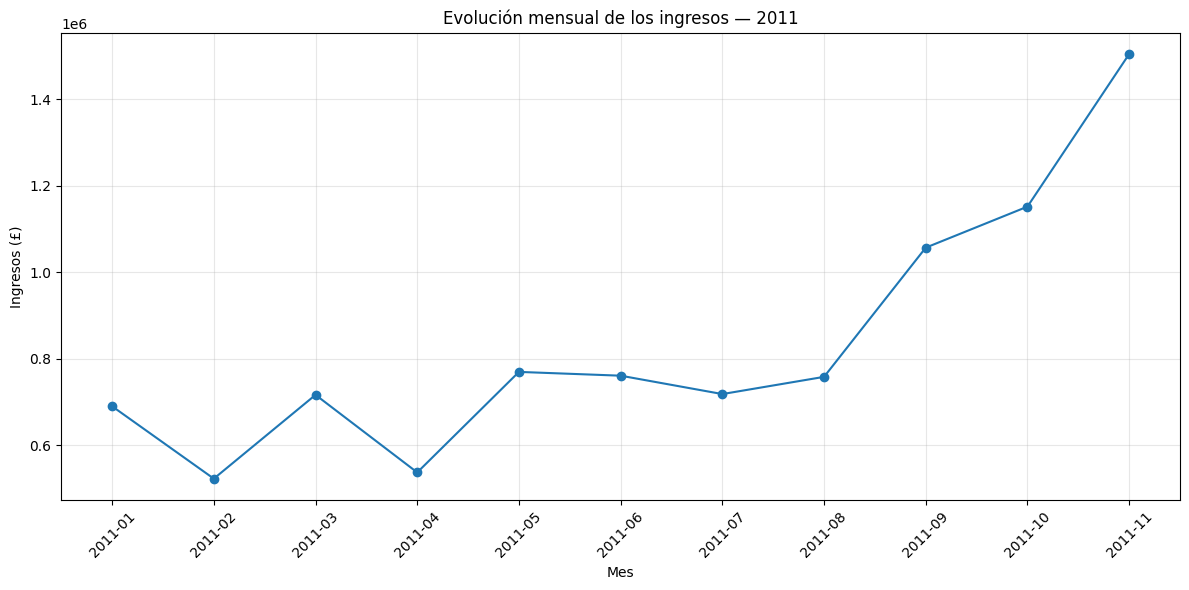

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    ingresos_2011["YearMonth"],
    ingresos_2011["Revenue"],
    marker="o"
)

plt.title("Evolución mensual de los ingresos — 2011")
plt.xlabel("Mes")
plt.ylabel("Ingresos (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Identificar el mes con mayor y menor ingreso
mes_mayor = ingresos_2011.loc[ingresos_2011["Revenue"].idxmax()]
mes_menor = ingresos_2011.loc[ingresos_2011["Revenue"].idxmin()]

# Comparar enero con noviembre
ingreso_enero = ingresos_2011.loc[
    ingresos_2011["YearMonth"] == "2011-01", "Revenue"
].iloc[0]

ingreso_noviembre = ingresos_2011.loc[
    ingresos_2011["YearMonth"] == "2011-11", "Revenue"
].iloc[0]

crecimiento = (
    (ingreso_noviembre - ingreso_enero) / ingreso_enero
) * 100

print(
    f"Mes con mayor ingreso: {mes_mayor['YearMonth']} "
    f"- £{mes_mayor['Revenue']:,.2f}"
)

print(
    f"Mes con menor ingreso: {mes_menor['YearMonth']} "
    f"- £{mes_menor['Revenue']:,.2f}"
)

print(f"Crecimiento de enero a noviembre: {crecimiento:.1f}%")

Mes con mayor ingreso: 2011-11 - £1,503,866.78
Mes con menor ingreso: 2011-02 - £522,545.56
Crecimiento de enero a noviembre: 118.0%


### Hallazgo 1 — Crecimiento de los ingresos durante 2011

**Evidencia visual:**  
La evolución mensual muestra fluctuaciones durante los primeros meses de 2011,
seguidas de un crecimiento más marcado a partir de septiembre. Noviembre
presenta el nivel de ingresos más alto del periodo analizado.

**Evidencia numérica:**  
- Mayor ingreso mensual: **noviembre de 2011 — £1,503,866.78**
- Menor ingreso mensual: **febrero de 2011 — £522,545.56**
- Crecimiento de enero a noviembre: **118.0%**

**Interpretación:**  
Los ingresos de noviembre fueron más del doble de los registrados en enero.
Además, septiembre, octubre y noviembre muestran una concentración creciente
de ingresos hacia el cierre del periodo analizado.

**Implicación de negocio:**  
El negocio podría reforzar inventario, campañas comerciales y capacidad
operativa durante los meses de mayor demanda observada. Sin embargo, debido a
que el dataset solo permite comparar un año completo, se necesitarían datos de
otros años para confirmar si este comportamiento corresponde a un patrón
estacional recurrente.

In [34]:
productos_ingresos = (
    ventas.groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

productos_ingresos.head(10)

,StockCode,Description,Revenue,UnitsSold,Orders
4150,DOT,DOTCOM POSTAGE,206248.77,706,706
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2669,47566,PARTY BUNTING,99445.23,18283,1685
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
4153,POST,POSTAGE,78101.88,3150,1126
4151,M,Manual,77750.27,6984,289
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994


### Preparación del análisis de productos

Antes de construir el ranking de productos se revisaron los registros con
mayores ingresos.

Se identificaron códigos como `DOT`, `POST` y `M`, correspondientes a cargos
de envío o registros manuales, por lo que no se consideran productos
comerciales en este análisis.

También se detectó una operación excepcional del producto
`PAPER CRAFT, LITTLE BIRDIE`: una venta de 80,995 unidades fue posteriormente
cancelada por la misma cantidad. Para evitar que esta operación revertida
distorsione el ranking de productos, se excluye de este análisis específico.

Estas exclusiones se aplican únicamente al análisis de productos y no
modifican el dataset original.

In [38]:
# Códigos que no representan productos comerciales
codigos_no_producto = ["DOT", "POST", "M"]

productos_validos = ventas[
    ~ventas["StockCode"].astype(str).isin(codigos_no_producto)
].copy()

# Excluir la operación excepcional posteriormente cancelada
productos_validos = productos_validos[
    productos_validos["StockCode"].astype(str) != "23843"
].copy()

print("Registros utilizados para análisis de productos:",
      len(productos_validos))

Registros utilizados para análisis de productos: 522729


In [39]:
top_productos = (
    productos_validos
    .groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_productos

,StockCode,Description,Revenue,UnitsSold,Orders
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
3772,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2668,47566,PARTY BUNTING,99445.23,18283,1685
3760,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
944,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
2874,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
2736,79321,CHILLI LIGHTS,54096.36,10302,661
2207,23298,SPOTTY BUNTING,42513.48,8320,1140


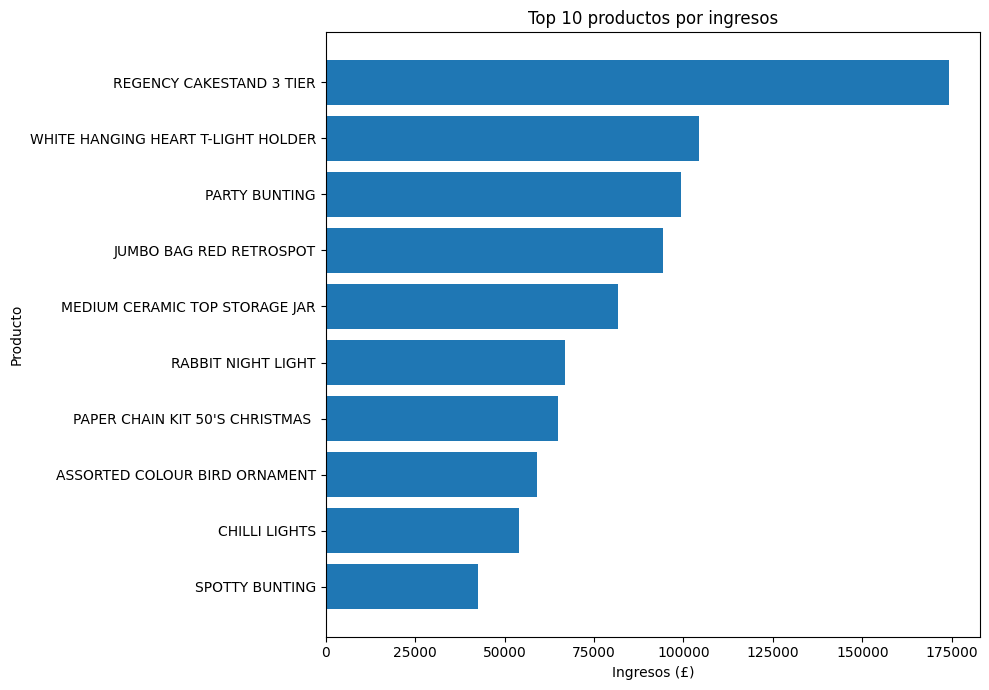

In [40]:
# Ordenar para que el producto con mayor ingreso quede arriba
top_productos_plot = top_productos.sort_values("Revenue", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    top_productos_plot["Description"],
    top_productos_plot["Revenue"]
)

plt.title("Top 10 productos por ingresos")
plt.xlabel("Ingresos (£)")
plt.ylabel("Producto")

plt.tight_layout()
plt.show()

### Hallazgo 2 — Productos que impulsan los ingresos

**Evidencia visual:**  
El ranking muestra diferencias importantes en la contribución de los productos
a los ingresos. `REGENCY CAKESTAND 3 TIER` ocupa la primera posición, seguido
por `WHITE HANGING HEART T-LIGHT HOLDER` y `PARTY BUNTING`.

**Evidencia numérica:**  
- `REGENCY CAKESTAND 3 TIER`: **£174,156.54**, 13,851 unidades y 1,988 pedidos.
- `WHITE HANGING HEART T-LIGHT HOLDER`: **£104,284.24**, 37,580 unidades y 2,189 pedidos.
- `PARTY BUNTING`: **£99,445.23**, 18,283 unidades y 1,685 pedidos.
- `JUMBO BAG RED RETROSPOT`: **£94,159.81**, 48,371 unidades y 2,089 pedidos.

**Interpretación:**  
Un mayor volumen de unidades vendidas no implica necesariamente mayores
ingresos. Algunos productos generan más ingresos con un menor número de
unidades, mientras que otros dependen principalmente de un alto volumen de
ventas.

**Implicación de negocio:**  
Los productos con alta contribución a ingresos y presencia frecuente en pedidos
pueden considerarse prioritarios para disponibilidad de inventario y acciones
comerciales. También conviene evaluar conjuntamente ingresos, volumen y
frecuencia de compra antes de tomar decisiones sobre el catálogo.

### Análisis de mercados

Para identificar los mercados con mayor contribución al negocio, se analizan
los ingresos, pedidos y clientes identificados por país.

Debido a que la empresa tiene su base principal en Reino Unido, también se
evaluarán por separado los mercados internacionales para evitar que la
concentración del mercado local oculte diferencias entre otros países.

In [41]:
mercados = (
    ventas.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

mercados["RevenueShare"] = (
    mercados["Revenue"] / mercados["Revenue"].sum() * 100
)

mercados.head(10)

,Country,Revenue,Orders,Customers,RevenueShare
36,United Kingdom,9001744.094,18019,3920,84.586078
24,Netherlands,285446.340,94,9,2.682234
10,EIRE,283140.520,288,3,2.660567
14,Germany,228678.400,457,94,2.148807
13,France,209625.370,392,87,1.969772
0,Australia,138453.810,57,9,1.301000
31,Spain,61558.560,90,30,0.578443
33,Switzerland,57067.600,54,21,0.536243
3,Belgium,41196.340,98,25,0.387107
32,Sweden,38367.830,36,8,0.360528


In [42]:
uk = mercados[mercados["Country"] == "United Kingdom"].iloc[0]

print(f"Ingresos Reino Unido: £{uk['Revenue']:,.2f}")
print(f"Participación en ingresos: {uk['RevenueShare']:.1f}%")
print(f"Pedidos: {int(uk['Orders']):,}")
print(f"Clientes identificados: {int(uk['Customers']):,}")

Ingresos Reino Unido: £9,001,744.09
Participación en ingresos: 84.6%
Pedidos: 18,019
Clientes identificados: 3,920


In [43]:
# Excluir Reino Unido para analizar los mercados internacionales
mercados_internacionales = (
    mercados[mercados["Country"] != "United Kingdom"]
    .sort_values("Revenue", ascending=False)
    .head(10)
)

mercados_internacionales[
    ["Country", "Revenue", "Orders", "Customers", "RevenueShare"]
]

,Country,Revenue,Orders,Customers,RevenueShare
24,Netherlands,285446.34,94,9,2.682234
10,EIRE,283140.52,288,3,2.660567
14,Germany,228678.40,457,94,2.148807
13,France,209625.37,392,87,1.969772
0,Australia,138453.81,57,9,1.301000
31,Spain,61558.56,90,30,0.578443
33,Switzerland,57067.60,54,21,0.536243
3,Belgium,41196.34,98,25,0.387107
32,Sweden,38367.83,36,8,0.360528
20,Japan,37416.37,19,8,0.351588


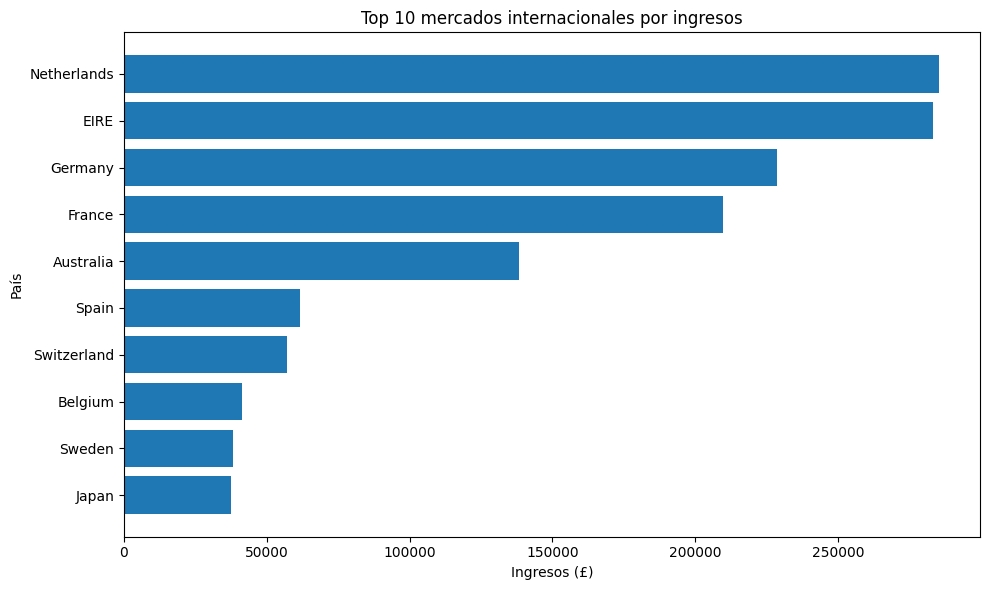

In [44]:
mercados_plot = mercados_internacionales.sort_values(
    "Revenue", ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    mercados_plot["Country"],
    mercados_plot["Revenue"]
)

plt.title("Top 10 mercados internacionales por ingresos")
plt.xlabel("Ingresos (£)")
plt.ylabel("País")

plt.tight_layout()
plt.show()

In [45]:
# Calcular ticket promedio por pedido
mercados["AvgOrderValue"] = (
    mercados["Revenue"] / mercados["Orders"]
)

# Top mercados internacionales por ingresos
comparacion_mercados = (
    mercados[mercados["Country"] != "United Kingdom"]
    .sort_values("Revenue", ascending=False)
    .head(10)
)

comparacion_mercados[
    ["Country", "Revenue", "Orders", "AvgOrderValue"]
]

,Country,Revenue,Orders,AvgOrderValue
24,Netherlands,285446.34,94,3036.663191
10,EIRE,283140.52,288,983.126806
14,Germany,228678.40,457,500.390372
13,France,209625.37,392,534.758597
0,Australia,138453.81,57,2429.014211
31,Spain,61558.56,90,683.984000
33,Switzerland,57067.60,54,1056.807407
3,Belgium,41196.34,98,420.370816
32,Sweden,38367.83,36,1065.773056
20,Japan,37416.37,19,1969.282632


In [46]:
comparacion_mercados[
    ["Country", "Revenue", "Orders", "AvgOrderValue"]
].round(2)

,Country,Revenue,Orders,AvgOrderValue
24,Netherlands,285446.34,94,3036.66
10,EIRE,283140.52,288,983.13
14,Germany,228678.40,457,500.39
13,France,209625.37,392,534.76
0,Australia,138453.81,57,2429.01
31,Spain,61558.56,90,683.98
33,Switzerland,57067.60,54,1056.81
3,Belgium,41196.34,98,420.37
32,Sweden,38367.83,36,1065.77
20,Japan,37416.37,19,1969.28


### Hallazgo 3 — Concentración de ingresos y diferencias entre mercados

**Evidencia visual:**  
El Reino Unido concentra la mayor parte de los ingresos del eCommerce. Al
analizar por separado los mercados internacionales, Netherlands y EIRE
presentan los mayores ingresos, seguidos por Germany y France.

**Evidencia numérica:**  
- Reino Unido genera aproximadamente **£9.00 millones**, equivalentes al
  **84.6% de los ingresos totales**.
- Netherlands genera **£285,446.34** con 94 pedidos y un ticket promedio de
  **£3,036.66**.
- EIRE genera **£283,140.52** con 288 pedidos y un ticket promedio de
  **£983.13**.
- Germany genera **£228,678.40** con 457 pedidos y un ticket promedio de
  **£500.39**.
- Australia genera **£138,453.81** con solo 57 pedidos y un ticket promedio de
  **£2,429.01**.

**Interpretación:**  
El negocio presenta una fuerte dependencia del mercado del Reino Unido.
Entre los mercados internacionales existen diferentes patrones de compra:
algunos generan ingresos mediante un mayor número de pedidos, mientras que
otros destacan por el elevado valor promedio de cada pedido.

**Implicación de negocio:**  
Netherlands y Australia podrían ser mercados interesantes para analizar con
mayor profundidad debido al alto valor promedio de sus pedidos. Germany y
France, por otro lado, presentan una mayor frecuencia de pedidos y podrían
representar oportunidades distintas de crecimiento.

Antes de definir una estrategia de expansión sería necesario analizar más
periodos y considerar factores como costos logísticos, adquisición de clientes
y rentabilidad por mercado.

In [47]:
# Número de facturas de venta y cancelación
pedidos_venta = ventas["InvoiceNo"].nunique()
pedidos_cancelados = cancelaciones["InvoiceNo"].nunique()

tasa_cancelacion = (
    pedidos_cancelados /
    (pedidos_venta + pedidos_cancelados)
) * 100

print(f"Pedidos de venta: {pedidos_venta:,}")
print(f"Pedidos cancelados: {pedidos_cancelados:,}")
print(f"Tasa de cancelación: {tasa_cancelacion:.2f}%")

Pedidos de venta: 19,960
Pedidos cancelados: 3,836
Tasa de cancelación: 16.12%


In [48]:
print("Registros de cancelación:", len(cancelaciones))

print(
    "Cantidades positivas en cancelaciones:",
    (cancelaciones["Quantity"] > 0).sum()
)

print(
    "Cantidades negativas en cancelaciones:",
    (cancelaciones["Quantity"] < 0).sum()
)

print(
    "Precios <= 0 en cancelaciones:",
    (cancelaciones["UnitPrice"] <= 0).sum()
)

Registros de cancelación: 9251
Cantidades positivas en cancelaciones: 0
Cantidades negativas en cancelaciones: 9251
Precios <= 0 en cancelaciones: 0


In [49]:
# Calcular valor monetario de cada cancelación
cancelaciones["CancelledValue"] = (
    cancelaciones["Quantity"] * cancelaciones["UnitPrice"]
).abs()

# Valor total cancelado
valor_cancelado = cancelaciones["CancelledValue"].sum()

# Compararlo con los ingresos de ventas
porcentaje_valor_cancelado = (
    valor_cancelado / ingresos_totales
) * 100

print(f"Valor total cancelado: £{valor_cancelado:,.2f}")
print(
    f"Valor cancelado respecto a los ingresos de ventas: "
    f"{porcentaje_valor_cancelado:.2f}%"
)

Valor total cancelado: £893,979.73
Valor cancelado respecto a los ingresos de ventas: 8.40%


In [50]:
top_cancelaciones = (
    cancelaciones.groupby("Description")
    .agg(
        CancelledValue=("CancelledValue", "sum"),
        CancelledUnits=("Quantity", lambda x: abs(x.sum())),
        CancelledInvoices=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("CancelledValue", ascending=False)
    .head(10)
)

top_cancelaciones

,Description,CancelledValue,CancelledUnits,CancelledInvoices
79,AMAZON FEE,235281.59,32,32
1184,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1093,Manual,146784.46,4066,223
1025,MEDIUM CERAMIC TOP STORAGE JAR,77479.64,74494,10
1305,POSTAGE,11871.24,147,124
1399,REGENCY CAKESTAND 3 TIER,9697.05,855,180
441,CRUK Commission,7933.43,16,16
271,Bank Charges,7340.64,25,25
1888,WHITE HANGING HEART T-LIGHT HOLDER,6624.30,2578,42
592,FAIRY CAKE FLANNEL ASSORTED COLOUR,6591.42,3150,3


### Hallazgo 4 — Cancelaciones y operaciones revertidas

**Evidencia numérica:**  
- Se identificaron **3,836 facturas canceladas**.
- La tasa de cancelación sobre el total de facturas de venta y cancelación fue de
  **16.12%**.
- El valor bruto registrado en las facturas de cancelación fue de
  **£893,979.73**, equivalente al **8.40% de los ingresos de ventas**.

**Análisis de las cancelaciones:**  
Las cancelaciones no corresponden exclusivamente a devoluciones de productos.
Entre los registros de mayor valor aparecen conceptos administrativos como
`AMAZON FEE`, `Manual`, `POSTAGE`, `CRUK Commission` y `Bank Charges`.

También se identificó una operación excepcional de
`PAPER CRAFT, LITTLE BIRDIE`, donde una venta de 80,995 unidades fue
posteriormente cancelada por la misma cantidad.

**Interpretación:**  
Las operaciones canceladas representan un volumen relevante dentro del
dataset, pero su valor no debe interpretarse directamente como pérdida de
ingresos por devoluciones de clientes, ya que incluye ajustes, cargos y
operaciones administrativas.

**Implicación de negocio:**  
Sería recomendable separar en el sistema las devoluciones comerciales de los
ajustes administrativos. Esto permitiría medir con mayor precisión la tasa de
devolución de productos e identificar las causas que generan mayor impacto
económico.

## 4. Conclusiones y recomendaciones

### Conclusiones

El análisis muestra que el eCommerce generó aproximadamente **£10.64 millones
en ventas válidas**, distribuidas en **19,960 pedidos**, con un ticket promedio
de **£533.17**.

Los principales hallazgos fueron:

1. **Crecimiento hacia el cierre de 2011.**  
   Noviembre fue el mes completo con mayores ingresos (**£1.50 millones**),
   mientras que febrero presentó el menor nivel (**£522.5 mil**). Los ingresos
   de noviembre fueron aproximadamente **118% superiores a los de enero**.

2. **Concentración en productos clave.**  
   `REGENCY CAKESTAND 3 TIER` fue el producto con mayor contribución a ingresos
   dentro del análisis de productos comerciales. El análisis también mostró
   que un mayor volumen de unidades no necesariamente implica mayores ingresos.

3. **Alta dependencia del Reino Unido.**  
   El Reino Unido representó aproximadamente **84.6% de los ingresos**.
   Fuera de este mercado, Netherlands y EIRE lideraron los ingresos
   internacionales, mientras que Netherlands y Australia destacaron por el
   elevado valor promedio de sus pedidos.

4. **Cancelaciones relevantes, pero heterogéneas.**  
   La tasa de facturas canceladas fue de **16.12%** y su valor bruto representó
   aproximadamente **8.40% de los ingresos de ventas**. Sin embargo, estas
   operaciones incluyen tanto productos como cargos y ajustes administrativos,
   por lo que no deben interpretarse directamente como devoluciones comerciales.

### Recomendaciones

- Reforzar inventario y capacidad operativa durante los periodos de mayor
  demanda observada.
- Priorizar productos considerando conjuntamente ingresos, volumen y frecuencia
  de compra.
- Analizar oportunidades de crecimiento internacional, especialmente en
  mercados con tickets promedio elevados.
- Reducir la dependencia del mercado británico mediante estrategias de
  diversificación geográfica.
- Separar devoluciones comerciales y ajustes administrativos en los sistemas de
  información para mejorar el seguimiento de cancelaciones.
- Incorporar datos de más años, costos y márgenes para evaluar estacionalidad,
  rentabilidad y oportunidades de expansión con mayor precisión.